# Policy Sharing in Multi-Agent Reinforcement Learning

이 프로젝트에서는 `simple_spread_v3` 환경에서 정책 공유 여부를 비교한다.

- Shared policy: 모든 에이전트가 하나의 actor-critic을 사용
- Independent policy: 에이전트마다 별도의 actor-critic을 사용
- 알고리즘: IPPO
- 결과: 평가 보상 그래프와 여러 개의 평가 영상

기존 30,000 agent steps 실험은 평가값의 변동이 커서, 이 버전에서는 학습량과 rollout 크기를 늘리고 PPO 업데이트를 조금 더 안정적으로 수정하였다.


In [98]:
import sys
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## 1. 환경 설정

처음 실행할 때 필요한 패키지는 프로젝트 폴더의 `requirements.txt`로 설치한다.

```bash
conda create -n marl-small python=3.11 -y
conda activate marl-small
pip install -r requirements.txt
jupyter notebook
```

In [99]:
import copy
import random
import time
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import Video, display
from mpe2 import simple_spread_v3
from torch.distributions import Categorical
from tqdm.auto import tqdm

## 2. 실험 설정

`FAST_RUN=True`는 코드 확인용이다. 제출용 결과를 만들 때는 `False`로 두고 실행한다.

기존 실험보다 학습량을 3배 늘렸고, 한 번에 수집하는 rollout과 평가 에피소드 수도 늘렸다.


In [100]:
USE_CUDA = True

DEVICE = torch.device(
    "cuda"
    if USE_CUDA and torch.cuda.is_available()
    else "cpu"
)

FAST_RUN = False

NUM_AGENTS = 3
MAX_CYCLES = 25
HIDDEN_SIZE = 64 * 4

SEEDS = [1] if FAST_RUN else [1, 2, 3]

TOTAL_AGENT_STEPS = 60000 if FAST_RUN else 90000
ROLLOUT_AGENT_STEPS = 6000 if FAST_RUN else 9000
EVAL_INTERVAL = 10000 if FAST_RUN else 15000
EVAL_EPISODES = 5 if FAST_RUN else 20
VIDEO_EPISODES = 1 if FAST_RUN else 3

ACTOR_LR = 3e-4
CRITIC_LR = 5e-4

GAMMA = 0.99
GAE_LAMBDA = 0.95

CLIP_COEF = 0.2
VALUE_CLIP_COEF = 0.2

UPDATE_EPOCHS = 5
MINIBATCH_SIZE = 512

ENTROPY_COEF_START = 0.005
ENTROPY_COEF_END = 0.0005

VALUE_COEF = 0.5
MAX_GRAD_NORM = 0.5
TARGET_KL = 0.03

REWARD_SCALE = 0.5
CURRICULUM_RATIO = 0.20

VARIANTS = {
    "shared": {
        "label": "Shared",
        "shared": True,
        "agent_id": False,
    },
    "shared_id": {
        "label": "Shared + Agent ID",
        "shared": True,
        "agent_id": True,
    },
    "independent": {
        "label": "Independent",
        "shared": False,
        "agent_id": False,
    },
}

for directory in ["models", "videos", "figures", "results"]:
    Path(directory).mkdir(parents=True, exist_ok=True)

print("device:", DEVICE)
print("seeds:", SEEDS)
print("steps per run:", TOTAL_AGENT_STEPS)

device: cpu
seeds: [1, 2, 3]
steps per run: 90000


## 3. 환경과 신경망

각 에이전트는 가까운 에이전트 1명과 landmark 2개만 관측한다. 공유 정책이 에이전트를 구분할 수 있도록 관측 뒤에 간단한 one-hot agent ID를 추가하였다.

초기 20% 구간은 curriculum stage 0에서 학습하고, 나머지 80%는 원래 환경인 stage 1에서 학습한다.


In [101]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_env(render_mode=None):
    return simple_spread_v3.parallel_env(
        N=NUM_AGENTS,
        local_ratio=0.5,
        max_cycles=MAX_CYCLES,
        continuous_actions=False,
        render_mode=render_mode,
        curriculum=True,
        terminate_on_success=True,
        num_agent_neighbors=1,
        num_landmark_neighbors=2,
    )


def set_stage(env, stage):
    env.unwrapped.set_curriculum_stage(stage)


env_test = make_env()
initial_obs, _ = env_test.reset(seed=0)

AGENT_NAMES = list(env_test.possible_agents)
BASE_OBS_DIM = len(initial_obs[AGENT_NAMES[0]])
ACTION_DIM = env_test.action_space(AGENT_NAMES[0]).n

env_test.close()

AGENT_TO_INDEX = {
    agent: index
    for index, agent in enumerate(AGENT_NAMES)
}


def prepare_obs(obs, agent, variant):
    obs = np.asarray(obs, dtype=np.float32)

    if not VARIANTS[variant]["agent_id"]:
        return obs

    agent_id = np.zeros(NUM_AGENTS, dtype=np.float32)
    agent_id[AGENT_TO_INDEX[agent]] = 1.0

    return np.concatenate([obs, agent_id])


def observation_dim(variant):
    if VARIANTS[variant]["agent_id"]:
        return BASE_OBS_DIM + NUM_AGENTS

    return BASE_OBS_DIM


def initialize_layer(layer, gain=np.sqrt(2)):
    nn.init.orthogonal_(layer.weight, gain)
    nn.init.constant_(layer.bias, 0.0)
    return layer


class ActorCritic(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.actor = nn.Sequential(
            initialize_layer(nn.Linear(input_dim, HIDDEN_SIZE)),
            nn.Tanh(),
            initialize_layer(nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE)),
            nn.Tanh(),
            initialize_layer(
                nn.Linear(HIDDEN_SIZE, ACTION_DIM),
                gain=0.01,
            ),
        )

        self.critic = nn.Sequential(
            initialize_layer(nn.Linear(input_dim, HIDDEN_SIZE)),
            nn.Tanh(),
            initialize_layer(nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE)),
            nn.Tanh(),
            initialize_layer(
                nn.Linear(HIDDEN_SIZE, 1),
                gain=1.0,
            ),
        )

        self.actor_optimizer = torch.optim.Adam(
            self.actor.parameters(),
            lr=ACTOR_LR,
            eps=1e-5,
        )

        self.critic_optimizer = torch.optim.Adam(
            self.critic.parameters(),
            lr=CRITIC_LR,
            eps=1e-5,
        )

    @torch.no_grad()
    def act(self, obs, deterministic=False):
        obs_tensor = torch.as_tensor(
            obs,
            dtype=torch.float32,
            device=DEVICE,
        ).unsqueeze(0)

        logits = self.actor(obs_tensor)
        distribution = Categorical(logits=logits)

        if deterministic:
            action = torch.argmax(logits, dim=-1)
        else:
            action = distribution.sample()

        value = self.critic(obs_tensor).squeeze(-1)

        return (
            int(action.item()),
            float(distribution.log_prob(action).item()),
            float(value.item()),
        )

    def evaluate_actor(self, obs, actions):
        logits = self.actor(obs)
        distribution = Categorical(logits=logits)

        return (
            distribution.log_prob(actions),
            distribution.entropy(),
        )

    def evaluate_value(self, obs):
        return self.critic(obs).squeeze(-1)


def policy_key(variant, agent):
    if VARIANTS[variant]["shared"]:
        return "shared"

    return agent


def make_policies(variant):
    input_dim = observation_dim(variant)

    if VARIANTS[variant]["shared"]:
        return {
            "shared": ActorCritic(input_dim).to(DEVICE)
        }

    return {
        agent: ActorCritic(input_dim).to(DEVICE)
        for agent in AGENT_NAMES
    }


def count_parameters(policies):
    return sum(
        parameter.numel()
        for policy in policies.values()
        for parameter in policy.parameters()
        if parameter.requires_grad
    )


print("agents:", AGENT_NAMES)
print("base observation dimension:", BASE_OBS_DIM)
print("action dimension:", ACTION_DIM)

for variant in VARIANTS:
    test_policies = make_policies(variant)

    print(
        variant,
        "input dimension:",
        observation_dim(variant),
        "parameters:",
        count_parameters(test_policies),
    )

agents: ['agent_0', 'agent_1', 'agent_2']
base observation dimension: 12
action dimension: 5
shared input dimension: 12 parameters: 139782
shared_id input dimension: 15 parameters: 141318
independent input dimension: 12 parameters: 419346


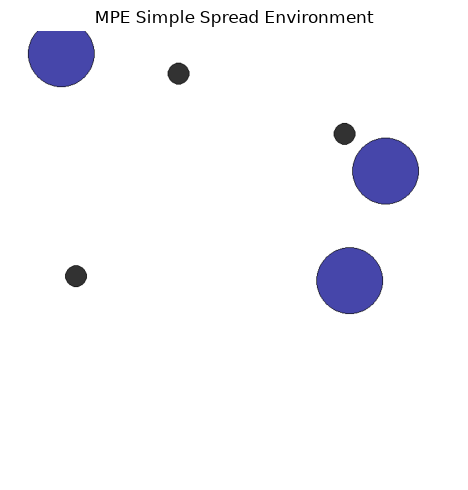

In [102]:
env_image = make_env(render_mode="rgb_array")
set_stage(env_image, 1)

_, _ = env_image.reset(seed=42)
frame = env_image.render()

env_image.close()

plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("MPE Simple Spread Environment")
plt.tight_layout()

plt.savefig(
    "figures/environment.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 4. Rollout 수집

PPO 업데이트에는 다음 안정화 방법을 사용한다.

- actor와 critic optimizer 분리
- clipped value loss
- entropy coefficient 감소
- learning rate 감소
- target KL을 이용한 과도한 업데이트 방지


In [103]:
def finish_trajectory(trajectory):
    rewards = np.asarray(
        trajectory["rewards"],
        dtype=np.float32,
    )

    values = np.asarray(
        trajectory["values"],
        dtype=np.float32,
    )

    dones = np.asarray(
        trajectory["dones"],
        dtype=np.float32,
    )

    advantages = np.zeros_like(rewards)
    gae = 0.0

    for index in reversed(range(len(rewards))):
        if index == len(rewards) - 1:
            next_value = 0.0
        else:
            next_value = values[index + 1]

        non_terminal = 1.0 - dones[index]

        delta = (
            rewards[index]
            + GAMMA * next_value * non_terminal
            - values[index]
        )

        gae = (
            delta
            + GAMMA
            * GAE_LAMBDA
            * non_terminal
            * gae
        )

        advantages[index] = gae

    return {
        "obs": np.asarray(
            trajectory["obs"],
            dtype=np.float32,
        ),
        "actions": np.asarray(
            trajectory["actions"],
            dtype=np.int64,
        ),
        "log_probs": np.asarray(
            trajectory["log_probs"],
            dtype=np.float32,
        ),
        "values": values,
        "advantages": advantages,
        "returns": advantages + values,
    }


def combine_batches(batch_list):
    keys = batch_list[0].keys()

    return {
        key: np.concatenate(
            [batch[key] for batch in batch_list]
        )
        for key in keys
    }


def collect_rollout(
    variant,
    policies,
    start_seed,
    stage,
):
    env = make_env()
    set_stage(env, stage)

    collected = {
        key: []
        for key in policies
    }

    episode_returns = []

    agent_steps = 0
    episode_number = 0

    SUCCESS_BONUS = 10.0

    while agent_steps < ROLLOUT_AGENT_STEPS:
        obs, _ = env.reset(seed=start_seed + episode_number)

        trajectories = {
            agent: {
                "obs": [],
                "actions": [],
                "log_probs": [],
                "rewards": [],
                "values": [],
                "dones": [],
            }
            for agent in env.agents
        }

        raw_returns = {
            agent: 0.0
            for agent in env.agents
        }

        while env.agents:
            active_agents = list(env.agents)

            actions = {}
            action_information = {}

            for agent in active_agents:
                key = policy_key(variant, agent)

                network_obs = prepare_obs(
                    obs[agent],
                    agent,
                    variant,
                )

                action_information[agent] = policies[key].act(network_obs)

                actions[agent] = action_information[agent][0]

            next_obs, rewards, terminations, truncations, _ = env.step(actions)

            successful = (
                bool(terminations)
                and all(terminations.values())
                and not any(truncations.values())
            )

            for agent in active_agents:
                action, log_prob, value = action_information[agent]

                done = (
                    terminations.get(agent, False)
                    or truncations.get(agent, False)
                )

                trajectories[agent]["obs"].append(
                    prepare_obs(
                        obs[agent],
                        agent,
                        variant,
                    )
                )

                trajectories[agent]["actions"].append(action)
                trajectories[agent]["log_probs"].append(log_prob)

                shaped_reward = float(rewards[agent])
                if successful:
                    shaped_reward += SUCCESS_BONUS

                trajectories[agent]["rewards"].append(
                    shaped_reward * REWARD_SCALE
                )

                trajectories[agent]["values"].append(value)
                trajectories[agent]["dones"].append(done)

                raw_returns[agent] += float(rewards[agent])

            obs = next_obs
            agent_steps += len(active_agents)

        for agent, trajectory in trajectories.items():
            key = policy_key(variant, agent)

            collected[key].append(
                finish_trajectory(trajectory)
            )

        episode_returns.append(
            np.mean(list(raw_returns.values()))
        )

        episode_number += 1

    env.close()

    combined = {
        key: combine_batches(value)
        for key, value in collected.items()
    }

    return (
        combined,
        agent_steps,
        float(np.mean(episode_returns)),
    )

In [104]:
def ppo_update(
    policy,
    batch,
    training_progress,
):
    obs = torch.as_tensor(
        batch["obs"],
        dtype=torch.float32,
        device=DEVICE,
    )

    actions = torch.as_tensor(
        batch["actions"],
        dtype=torch.long,
        device=DEVICE,
    )

    old_log_probs = torch.as_tensor(
        batch["log_probs"],
        dtype=torch.float32,
        device=DEVICE,
    )

    old_values = torch.as_tensor(
        batch["values"],
        dtype=torch.float32,
        device=DEVICE,
    )

    returns = torch.as_tensor(
        batch["returns"],
        dtype=torch.float32,
        device=DEVICE,
    )

    advantages = torch.as_tensor(
        batch["advantages"],
        dtype=torch.float32,
        device=DEVICE,
    )

    advantages = (
        advantages - advantages.mean()
    ) / (
        advantages.std(unbiased=False) + 1e-8
    )

    remaining_ratio = max(
        0.10,
        1.0 - training_progress,
    )

    for group in policy.actor_optimizer.param_groups:
        group["lr"] = ACTOR_LR * remaining_ratio

    for group in policy.critic_optimizer.param_groups:
        group["lr"] = CRITIC_LR * remaining_ratio

    entropy_coef = (
        ENTROPY_COEF_START
        + (
            ENTROPY_COEF_END
            - ENTROPY_COEF_START
        )
        * training_progress
    )

    indices = np.arange(len(obs))

    actor_losses = []
    critic_losses = []
    entropies = []
    approximate_kls = []

    for _ in range(UPDATE_EPOCHS):
        np.random.shuffle(indices)
        epoch_kls = []

        for start in range(
            0,
            len(indices),
            MINIBATCH_SIZE,
        ):
            minibatch = indices[
                start:start + MINIBATCH_SIZE
            ]

            index = torch.as_tensor(
                minibatch,
                dtype=torch.long,
                device=DEVICE,
            )

            new_log_prob, entropy = policy.evaluate_actor(
                obs[index],
                actions[index],
            )

            log_ratio = (
                new_log_prob
                - old_log_probs[index]
            )

            ratio = torch.exp(log_ratio)

            unclipped_loss = (
                -advantages[index]
                * ratio
            )

            clipped_loss = (
                -advantages[index]
                * torch.clamp(
                    ratio,
                    1.0 - CLIP_COEF,
                    1.0 + CLIP_COEF,
                )
            )

            actor_loss = torch.maximum(
                unclipped_loss,
                clipped_loss,
            ).mean()

            actor_objective = (
                actor_loss
                - entropy_coef
                * entropy.mean()
            )

            policy.actor_optimizer.zero_grad()
            actor_objective.backward()

            nn.utils.clip_grad_norm_(
                policy.actor.parameters(),
                MAX_GRAD_NORM,
            )

            policy.actor_optimizer.step()

            value = policy.evaluate_value(
                obs[index]
            )

            clipped_value = (
                old_values[index]
                + torch.clamp(
                    value - old_values[index],
                    -VALUE_CLIP_COEF,
                    VALUE_CLIP_COEF,
                )
            )

            normal_value_loss = (
                value - returns[index]
            ).pow(2)

            clipped_value_loss = (
                clipped_value - returns[index]
            ).pow(2)

            critic_loss = (
                0.5
                * torch.maximum(
                    normal_value_loss,
                    clipped_value_loss,
                ).mean()
            )

            policy.critic_optimizer.zero_grad()

            (
                VALUE_COEF
                * critic_loss
            ).backward()

            nn.utils.clip_grad_norm_(
                policy.critic.parameters(),
                MAX_GRAD_NORM,
            )

            policy.critic_optimizer.step()

            with torch.no_grad():
                approximate_kl = (
                    (ratio - 1.0)
                    - log_ratio
                ).mean()

            actor_losses.append(
                float(actor_loss.item())
            )

            critic_losses.append(
                float(critic_loss.item())
            )

            entropies.append(
                float(entropy.mean().item())
            )

            epoch_kls.append(
                float(approximate_kl.item())
            )

        mean_epoch_kl = float(
            np.mean(epoch_kls)
        )

        approximate_kls.append(mean_epoch_kl)

        if mean_epoch_kl > TARGET_KL:
            break

    return {
        "actor_loss": float(np.mean(actor_losses)),
        "critic_loss": float(np.mean(critic_losses)),
        "entropy": float(np.mean(entropies)),
        "approx_kl": float(np.mean(approximate_kls)),
    }

## 5. 평가와 학습 함수

평가는 매번 같은 초기 seed 집합에서 여러 에피소드로 수행한다. 학습 도중 가장 좋은 평가 결과를 보인 모델을 저장하고, 학습이 끝나면 마지막 모델이 아니라 **best model**을 다시 불러온다.


In [105]:
def normalized_action_diversity(actions):
    if len(actions) <= 1:
        return 0.0

    unique_actions = len(set(actions.values()))

    return (
        unique_actions - 1
    ) / (
        len(actions) - 1
    )

@torch.no_grad()
def evaluate_policy(
    variant,
    policies,
    episodes=20,
    seed=10000,
):
    env = make_env()
    set_stage(env, 1)

    episode_returns = []
    episode_lengths = []
    episode_successes = []
    episode_diversities = []

    for episode in range(episodes):
        obs, _ = env.reset(
            seed=seed + episode
        )

        returns = {
            agent: 0.0
            for agent in env.agents
        }

        step_count = 0
        diversity_values = []

        last_terminations = {}
        last_truncations = {}

        while env.agents:
            actions = {}

            for agent in env.agents:
                key = policy_key(
                    variant,
                    agent,
                )

                network_obs = prepare_obs(
                    obs[agent],
                    agent,
                    variant,
                )

                actions[agent] = policies[key].act(
                    network_obs,
                    deterministic=True,
                )[0]

            diversity_values.append(
                normalized_action_diversity(actions)
            )

            obs, rewards, last_terminations, last_truncations, _, = env.step(actions)

            for agent, reward in rewards.items():
                returns[agent] += float(reward)

            step_count += 1

        successful = (
            bool(last_terminations)
            and all(last_terminations.values())
            and not any(last_truncations.values())
        )
        episode_returns.append(
            np.mean(list(returns.values()))
        )

        episode_lengths.append(step_count)
        episode_successes.append(float(successful))

        episode_diversities.append(
            float(np.mean(diversity_values))
        )

    env.close()

    return {
        "mean_return": float(np.mean(episode_returns)),
        "std_return": float(np.std(episode_returns)),
        "success_rate": float(np.mean(episode_successes)),
        "mean_length": float(np.mean(episode_lengths)),
        "action_diversity": float(
            np.mean(episode_diversities)
        ),
    }


def evaluate_random_policy(
    episodes=20,
    seed=10000,
):
    env = make_env()
    set_stage(env, 1)

    returns_list = []
    lengths = []
    successes = []
    diversities = []

    for episode in range(episodes):
        _, _ = env.reset(seed=seed + episode)

        rng = np.random.default_rng(
            seed + episode
        )

        returns = {
            agent: 0.0
            for agent in env.agents
        }

        step_count = 0
        diversity_values = []

        last_terminations = {}
        last_truncations = {}

        while env.agents:
            actions = {
                agent: int(
                    rng.integers(ACTION_DIM)
                )
                for agent in env.agents
            }

            diversity_values.append(
                normalized_action_diversity(actions)
            )

            obs, rewards, last_terminations, last_truncations, _, = env.step(actions)

            for agent, reward in rewards.items():
                returns[agent] += float(reward)

            step_count += 1

        successful = (
            bool(last_terminations)
            and all(last_terminations.values())
            and not any(last_truncations.values())
        )

        returns_list.append(
            np.mean(list(returns.values()))
        )

        lengths.append(step_count)
        successes.append(float(successful))

        diversities.append(
            float(np.mean(diversity_values))
        )

    env.close()

    return {
        "mean_return": float(np.mean(returns_list)),
        "std_return": float(np.std(returns_list)),
        "success_rate": float(np.mean(successes)),
        "mean_length": float(np.mean(lengths)),
        "action_diversity": float(np.mean(diversities)),
    }

## 6. Shared policy와 Independent policy 학습

소규모 과제 범위를 유지하기 위해 seed는 1회 사용한다. 다만 각 평가 시 20개의 고정된 초기 상태를 사용하므로 기존 8회 평가보다 곡선의 변동이 줄어든다.

`FAST_RUN=False`에서는 두 방식 모두 90,000 agent steps를 학습한다. 시간이 충분하면 `TOTAL_AGENT_STEPS`를 120,000~150,000으로 늘릴 수 있다.


In [106]:
def save_model(
    variant,
    policies,
    seed,
):
    model_path = (
        Path("models")
        / f"{variant}_seed{seed}.pt"
    )

    torch.save(
        {
            "variant": variant,
            "seed": seed,
            "states": {
                key: policy.state_dict()
                for key, policy in policies.items()
            },
        },
        model_path,
    )

    return model_path


def train(
    variant,
    seed,
):
    set_seed(seed)

    policies = make_policies(variant)

    history = []

    total_steps = 0
    next_evaluation = EVAL_INTERVAL
    rollout_index = 0

    evaluation_seed = 10_000 + seed * 100

    initial_metrics = evaluate_policy(
        variant,
        policies,
        episodes=EVAL_EPISODES,
        seed=evaluation_seed,
    )

    best_metrics = initial_metrics.copy()
    best_step = 0

    best_states = {
        key: copy.deepcopy(policy.state_dict())
        for key, policy in policies.items()
    }

    history.append({
        "variant": variant,
        "seed": seed,
        "agent_steps": 0,
        "train_return": np.nan,
        "eval_return": initial_metrics["mean_return"],
        "eval_std": initial_metrics["std_return"],
        "success_rate": initial_metrics["success_rate"],
        "mean_length": initial_metrics["mean_length"],
        "action_diversity": initial_metrics["action_diversity"],
        "actor_loss": np.nan,
        "critic_loss": np.nan,
        "entropy": np.nan,
        "approx_kl": np.nan,
    })

    progress_bar = tqdm(
        total=TOTAL_AGENT_STEPS,
        desc=f"{variant}, seed={seed}",
        unit="agent-step",
    )

    while total_steps < TOTAL_AGENT_STEPS:
        curriculum_stage = (
            0
            if total_steps
            < TOTAL_AGENT_STEPS * CURRICULUM_RATIO
            else 1
        )

        batches, new_steps, train_return = collect_rollout(
            variant,
            policies,
            start_seed=(
                seed * 100_000
                + rollout_index * 100
            ),
            stage=curriculum_stage,
        )

        training_progress = min(
            1.0,
            total_steps / TOTAL_AGENT_STEPS,
        )

        update_results = []

        for key, policy in policies.items():
            update_results.append(
                ppo_update(
                    policy,
                    batches[key],
                    training_progress,
                )
            )

        total_steps += new_steps
        rollout_index += 1

        progress_bar.update(
            min(
                new_steps,
                TOTAL_AGENT_STEPS
                - progress_bar.n,
            )
        )

        should_evaluate = (
            total_steps >= next_evaluation
            or total_steps >= TOTAL_AGENT_STEPS
        )

        if not should_evaluate:
            continue

        metrics = evaluate_policy(
            variant,
            policies,
            episodes=EVAL_EPISODES,
            seed=evaluation_seed,
        )

        row = {
            "variant": variant,
            "seed": seed,
            "agent_steps": total_steps,
            "train_return": train_return,
            "eval_return": metrics["mean_return"],
            "eval_std": metrics["std_return"],
            "success_rate": metrics["success_rate"],
            "mean_length": metrics["mean_length"],
            "action_diversity": metrics["action_diversity"],
            "actor_loss": float(np.mean([
                result["actor_loss"]
                for result in update_results
            ])),
            "critic_loss": float(np.mean([
                result["critic_loss"]
                for result in update_results
            ])),
            "entropy": float(np.mean([
                result["entropy"]
                for result in update_results
            ])),
            "approx_kl": float(np.mean([
                result["approx_kl"]
                for result in update_results
            ])),
        }

        history.append(row)

        print(
            f"{variant:12s} "
            f"seed={seed}, "
            f"steps={total_steps:7d}, "
            f"return={metrics['mean_return']:7.2f}, "
            f"success={metrics['success_rate']:.2f}"
        )

        if (
            metrics["mean_return"]
            > best_metrics["mean_return"]
        ):
            best_metrics = metrics.copy()
            best_step = total_steps

            best_states = {
                key: copy.deepcopy(
                    policy.state_dict()
                )
                for key, policy in policies.items()
            }

            save_model(
                variant,
                policies,
                seed,
            )

        while next_evaluation <= total_steps:
            next_evaluation += EVAL_INTERVAL

    progress_bar.close()

    # 마지막 정책이 아니라 가장 성능이 좋았던 정책 복원
    for key, policy in policies.items():
        policy.load_state_dict(
            best_states[key]
        )

    save_model(
        variant,
        policies,
        seed,
    )

    summary = {
        "variant": variant,
        "seed": seed,
        "best_step": best_step,
        "best_return": best_metrics["mean_return"],
        "return_std": best_metrics["std_return"],
        "success_rate": best_metrics["success_rate"],
        "mean_length": best_metrics["mean_length"],
        "action_diversity": best_metrics["action_diversity"],
        "parameter_count": count_parameters(policies),
    }

    return (
        policies,
        pd.DataFrame(history),
        summary,
    )

In [107]:
start_time = time.time()

all_histories = []
run_summaries = []

trained_models = {}

for variant in VARIANTS:
    for seed in SEEDS:
        policies, history, summary = train( variant, seed )

        trained_models[(variant, seed)] = policies
        all_histories.append(history)
        run_summaries.append(summary)


training_history = pd.concat(
    all_histories,
    ignore_index=True,
)

run_summary = pd.DataFrame(
    run_summaries
)

training_history.to_csv(
    "results/training_history.csv",
    index=False,
)

run_summary.to_csv(
    "results/run_summary.csv",
    index=False,
)


random_metrics = evaluate_random_policy(
    episodes=EVAL_EPISODES,
    seed=10100,
)

elapsed_minutes = (
    time.time() - start_time
) / 60

print(
    f"Total training time: "
    f"{elapsed_minutes:.1f} minutes"
)

print("Random baseline:")
print(random_metrics)

run_summary

shared, seed=1:   0%|          | 0/90000 [00:00<?, ?agent-step/s]

shared       seed=1, steps=  18000, return= -23.11, success=0.00
shared       seed=1, steps=  36000, return= -19.74, success=0.00
shared       seed=1, steps=  45000, return= -18.80, success=0.00
shared       seed=1, steps=  63000, return= -18.35, success=0.00
shared       seed=1, steps=  81000, return= -17.39, success=0.00
shared       seed=1, steps=  90048, return= -17.13, success=0.00


shared, seed=2:   0%|          | 0/90000 [00:00<?, ?agent-step/s]

shared       seed=2, steps=  18012, return= -21.58, success=0.00
shared       seed=2, steps=  36063, return= -20.31, success=0.00
shared       seed=2, steps=  45063, return= -19.55, success=0.00
shared       seed=2, steps=  63063, return= -18.07, success=0.00
shared       seed=2, steps=  81114, return= -17.31, success=0.05
shared       seed=2, steps=  90114, return= -16.95, success=0.00


shared, seed=3:   0%|          | 0/90000 [00:00<?, ?agent-step/s]

...

independent, seed=2:   0%|          | 0/90000 [00:00<?, ?agent-step/s]

independent  seed=2, steps=  18000, return= -22.17, success=0.00
independent  seed=2, steps=  36000, return= -20.22, success=0.00
independent  seed=2, steps=  45000, return= -20.83, success=0.00
independent  seed=2, steps=  63000, return= -19.75, success=0.00
independent  seed=2, steps=  81012, return= -19.38, success=0.00
independent  seed=2, steps=  90012, return= -19.01, success=0.00


independent, seed=3:   0%|          | 0/90000 [00:00<?, ?agent-step/s]

independent  seed=3, steps=  18000, return= -24.38, success=0.00
independent  seed=3, steps=  36000, return= -25.68, success=0.00
independent  seed=3, steps=  45000, return= -22.67, success=0.00
independent  seed=3, steps=  63000, return= -20.95, success=0.00
independent  seed=3, steps=  81000, return= -21.66, success=0.00
independent  seed=3, steps=  90000, return= -21.95, success=0.00
Total training time: 5.5 minutes
Random baseline:
{'mean_return': -23.429145563602226, 'std_return': 5.398698969226845, 'success_rate': 0.0, 'mean_length': 25.0, 'action_diversity': 0.7210000000000001}


,variant,seed,best_step,best_return,return_std,success_rate,mean_length,action_diversity,parameter_count
0,shared,1,90048,-17.127377,5.485783,0.0,25.0,0.703,139782
1,shared,2,90114,-16.950848,5.063452,0.0,25.0,0.770,139782
2,shared,3,90000,-17.469781,4.038755,0.0,25.0,0.714,139782
3,shared_id,1,90000,-17.186656,3.938564,0.0,25.0,0.655,141318
4,shared_id,2,45000,-17.606611,4.545616,0.0,25.0,0.545,141318
5,shared_id,3,90000,-17.433772,3.759775,0.0,25.0,0.701,141318
6,independent,1,90000,-20.809096,6.715079,0.0,25.0,0.741,419346
7,independent,2,90012,-19.010425,4.964580,0.0,25.0,0.724,419346
8,independent,3,63000,-20.950912,4.444949,0.0,25.0,0.711,419346


## 7. 학습 결과

점은 20개 평가 에피소드의 평균이고, 옅은 영역은 평가 표준편차이다. 이 환경에서는 보상이 음수이므로 값이 0에 가까울수록 성능이 좋다.


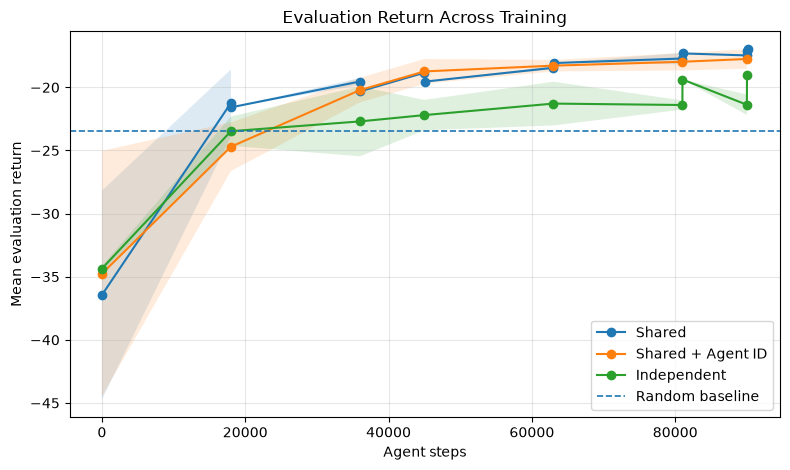

In [108]:
aggregated_history = (
    training_history
    .groupby(
        ["variant", "agent_steps"],
        as_index=False,
    )
    .agg(
        mean_return=("eval_return", "mean"),
        std_return=("eval_return", "std"),
        mean_success=("success_rate", "mean"),
    )
)

aggregated_history["std_return"] = (
    aggregated_history["std_return"]
    .fillna(0.0)
)


plt.figure(figsize=(8, 4.8))

for variant in VARIANTS:
    group = (
        aggregated_history[
            aggregated_history["variant"]
            == variant
        ]
        .sort_values("agent_steps")
    )

    x = group["agent_steps"].to_numpy()
    mean = group["mean_return"].to_numpy()
    std = group["std_return"].to_numpy()

    plt.plot(
        x,
        mean,
        marker="o",
        label=VARIANTS[variant]["label"],
    )

    plt.fill_between(
        x,
        mean - std,
        mean + std,
        alpha=0.15,
    )


plt.axhline(
    random_metrics["mean_return"],
    linestyle="--",
    linewidth=1.2,
    label="Random baseline",
)

plt.xlabel("Agent steps")
plt.ylabel("Mean evaluation return")

plt.title(
    "Evaluation Return Across Training"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/learning_curve.png",
    dpi=180,
)

plt.show()

## 8. 평가 영상 저장

학습이 끝난 뒤 복원된 best model을 사용한다. Shared와 Independent는 동일한 초기 seed에서 평가하므로 영상끼리 직접 비교할 수 있다.


In [109]:
variant_order = list(VARIANTS.keys())

final_statistics = (
    run_summary
    .groupby("variant")
    .agg(
        return_mean=("best_return", "mean"),
        return_std=("best_return", "std"),
        success_mean=("success_rate", "mean"),
        success_std=("success_rate", "std"),
        length_mean=("mean_length", "mean"),
        diversity_mean=("action_diversity", "mean"),
        parameters=("parameter_count", "first"),
    )
    .reindex(variant_order)
)

final_statistics = (
    final_statistics.fillna(0.0)
)

final_statistics

,return_mean,return_std,success_mean,success_std,length_mean,diversity_mean,parameters
variant,,,,,,,
shared,-17.182669,0.263848,0.0,0.0,25.0,0.729000,139782
shared_id,-17.409013,0.211069,0.0,0.0,25.0,0.633667,141318
independent,-20.256811,1.081728,0.0,0.0,25.0,0.725333,419346


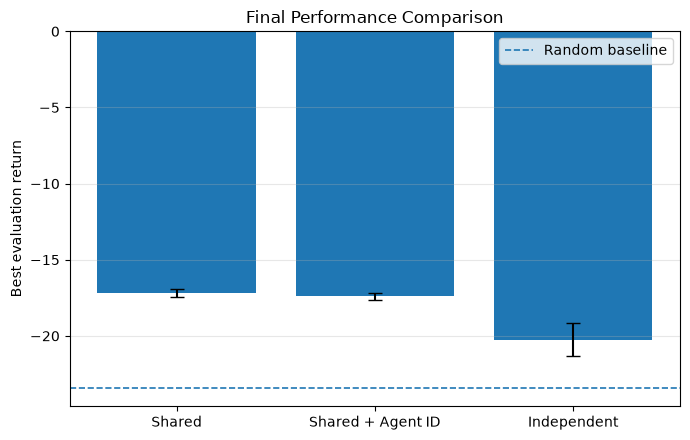

In [110]:
labels = [
    VARIANTS[variant]["label"]
    for variant in variant_order
]

plt.figure(figsize=(7, 4.5))

plt.bar(
    labels,
    final_statistics["return_mean"],
    yerr=final_statistics["return_std"],
    capsize=5,
)

plt.axhline(
    random_metrics["mean_return"],
    linestyle="--",
    linewidth=1.2,
    label="Random baseline",
)

plt.ylabel("Best evaluation return")
plt.title("Final Performance Comparison")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/final_return.png",
    dpi=180,
)

plt.show()

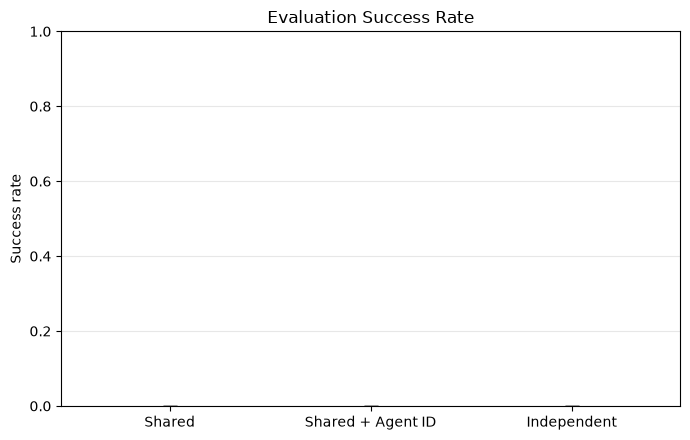

In [111]:
plt.figure(figsize=(7, 4.5))

plt.bar(
    labels,
    final_statistics["success_mean"],
    yerr=final_statistics["success_std"],
    capsize=5,
)

plt.ylabel("Success rate")
plt.ylim(0.0, 1.0)
plt.title("Evaluation Success Rate")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/success_rate.png",
    dpi=180,
)

plt.show()

In [112]:
report_table = final_statistics.reset_index()

report_table["method"] = report_table[
    "variant"
].map({
    key: value["label"]
    for key, value in VARIANTS.items()
})

report_table[
    [
        "method",
        "return_mean",
        "return_std",
        "success_mean",
        "length_mean",
        "diversity_mean",
        "parameters",
    ]
].round(3)

,method,return_mean,return_std,success_mean,length_mean,diversity_mean,parameters
0,Shared,-17.183,0.264,0.0,25.0,0.729,139782
1,Shared + Agent ID,-17.409,0.211,0.0,25.0,0.634,141318
2,Independent,-20.257,1.082,0.0,25.0,0.725,419346


In [113]:
@torch.no_grad()
def save_evaluation_videos(
    variant,
    policies,
    episodes=3,
    seed=50000,
):
    output_directory = (
        Path("videos")
        / variant
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    saved_files = []
    metric_rows = []

    for episode in range(episodes):
        reset_seed = seed + episode

        env = make_env(
            render_mode="rgb_array"
        )

        set_stage(env, 1)

        obs, _ = env.reset(
            seed=reset_seed
        )

        returns = {
            agent: 0.0
            for agent in env.agents
        }

        step_count = 0
        diversity_values = []

        last_terminations = {}
        last_truncations = {}

        video_path = (
            output_directory
            / f"episode_{episode + 1:02d}.mp4"
        )

        writer = imageio.get_writer(
            video_path,
            fps=10,
        )

        writer.append_data(env.render())

        while env.agents:
            actions = {}

            for agent in env.agents:
                key = policy_key(
                    variant,
                    agent,
                )

                network_obs = prepare_obs(
                    obs[agent],
                    agent,
                    variant,
                )

                actions[agent] = policies[key].act(
                    network_obs,
                    deterministic=True,
                )[0]

            diversity_values.append(
                normalized_action_diversity(actions)
            )

            obs, rewards, last_terminations, last_truncations, _, = env.step(actions)

            for agent, reward in rewards.items():
                returns[agent] += float(reward)

            writer.append_data(env.render())
            step_count += 1

        writer.close()
        env.close()

        successful = (
            bool(last_terminations)
            and all(last_terminations.values())
            and not any(last_truncations.values())
        )

        saved_files.append(str(video_path))

        metric_rows.append({
            "variant": variant,
            "episode": episode + 1,
            "seed": reset_seed,
            "mean_return": float(
                np.mean(list(returns.values()))
            ),
            "success": float(successful),
            "episode_length": step_count,
            "action_diversity": float(
                np.mean(diversity_values)
            ),
            "video_path": str(video_path),
        })

    return (
        saved_files,
        pd.DataFrame(metric_rows),
    )

In [114]:
best_seed_rows = run_summary.loc[
    run_summary
    .groupby("variant")["best_return"]
    .idxmax()
]

all_video_metrics = []
saved_video_paths = {}

for _, row in best_seed_rows.iterrows():
    variant = row["variant"]
    seed = int(row["seed"])

    policies = trained_models[
        (variant, seed)
    ]

    paths, metrics = save_evaluation_videos(
        variant,
        policies,
        episodes=VIDEO_EPISODES,
        seed=50000,
    )

    saved_video_paths[variant] = paths
    all_video_metrics.append(metrics)


video_metrics = pd.concat(
    all_video_metrics,
    ignore_index=True,
)

video_metrics.to_csv(
    "results/video_metrics.csv",
    index=False,
)

video_metrics

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input ima

,variant,episode,seed,mean_return,success,episode_length,action_diversity,video_path
0,independent,1,50000,-19.157333,0.0,25,0.52,videos\independent\episode_01.mp4
1,independent,2,50001,-23.095063,0.0,25,0.84,videos\independent\episode_02.mp4
2,independent,3,50002,-16.274602,0.0,25,0.72,videos\independent\episode_03.mp4
3,shared,1,50000,-18.562295,0.0,25,0.68,videos\shared\episode_01.mp4
4,shared,2,50001,-20.627439,0.0,25,0.74,videos\shared\episode_02.mp4
5,shared,3,50002,-17.256270,0.0,25,0.78,videos\shared\episode_03.mp4
6,shared_id,1,50000,-12.463090,0.0,25,0.62,videos\shared_id\episode_01.mp4
7,shared_id,2,50001,-20.866213,0.0,25,0.64,videos\shared_id\episode_02.mp4
8,shared_id,3,50002,-13.760037,0.0,25,0.58,videos\shared_id\episode_03.mp4


## 9. 영상 확인

아래 셀은 각 방식의 첫 번째 평가 영상을 노트북 안에서 보여준다. 나머지 영상은 `videos/shared`, `videos/independent` 폴더에서 확인한다.

In [115]:
for variant in VARIANTS:
    print(VARIANTS[variant]["label"])

    display(
        Video(
            saved_video_paths[variant][0],
            embed=False,
            width=500,
        )
    )

Shared


Shared + Agent ID


Independent
